### Quick Start Code Cell

In [1]:
savefile_path = '/Users/austin/Desktop/2026_05_01_currentSeries/'

In [2]:
import subprocess
import time
import os
import tango
import json
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# first do lsof -i:9000
# kill {PID}

# if kernel is dying, reset the environment (click a different one then click back)

In [4]:
# ── Config ────────────────────────────────────────────────────────────────────
DB_HOST = "localhost"
DB_PORT = 9000
server_list = [("stage", "asyncroscopy.hardware.STAGE"),
                     ("scan", "asyncroscopy.hardware.SCAN"),
                     ("eds", "asyncroscopy.detectors.EDS"),
                     ("camera", "asyncroscopy.detectors.CAMERA")]
# ─────────────────────────────────────────────────────────────────────────────

PROJECT_DIR = os.path.dirname(os.getcwd())
os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"
env = {**os.environ, "TANGO_HOST": f"{DB_HOST}:{DB_PORT}"}
processes = {}

def popen(cmd):
    return subprocess.Popen(cmd, env=env, cwd=PROJECT_DIR, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

def wait_for_device(name, timeout=60, interval=1):
    print(f"  Waiting for {name}...", end="", flush=True)
    start = time.time()
    while time.time() - start < timeout:
        try:
            tango.DeviceProxy(name).ping()
            print(f" ✅ ready ({time.time()-start:.1f}s)"); return True
        except:
            print(".", end="", flush=True); time.sleep(interval)
    print(f" ❌ timed out after {timeout}s"); return False

def check_processes(*names):
    for name in names:
        p = processes[name]
        print(f"\n─── {name} (PID {p.pid}) ───\n  Running: {p.poll() is None}")
        for label, fd in [("STDOUT", p.stdout), ("STDERR", p.stderr)]:
            try: print(f"  {label}: {fd.read1(4096).decode() or '(empty)'}")
            except: print(f"  {label}: (no output yet)")

# Kill old processes (if any)
print("Clearing old processes...")
for cmd in [f"kill -9 $(lsof -t -i:{DB_PORT}) 2>/dev/null || true",
            *[f"pkill -f '{module.split('.')[-1]} {name}_instance' 2>/dev/null || true"
              for name, module in server_list],
            "pkill -f 'ThermoMicroscope microscope_instance' 2>/dev/null || true"]:
    subprocess.run(cmd, shell=True)
time.sleep(2)

# Start DB
print(f"Project dir: {PROJECT_DIR}\nStarting Tango Database...")
processes["database"] = popen(["uv", "run", "python", "-m", "tango.databaseds.database", "2"])
print("  Waiting for database...", end="", flush=True)
for _ in range(30):
    try: tango.Database(DB_HOST, DB_PORT); print(" ✅ ready"); break
    except: print(".", end="", flush=True); time.sleep(1)

# Register devices
print("Registering devices...")
r = subprocess.run(["uv", "run", "scripts/2_register_devices.py"], env=env, cwd=PROJECT_DIR, capture_output=True, text=True)
print(r.stdout.strip())
if r.returncode != 0:
    print("ERROR:", r.stderr); raise RuntimeError("Device registration failed — stopping here.")

# Start servers
print("Starting device servers...")
for name, module in server_list:
    processes[name] = popen(["uv", "run", "python", "-m", module, f"{name}_instance"])

if not all(wait_for_device(f"asyncroscopy/{d}/default") for d in ["stage", "scan", "eds"]):
    raise RuntimeError("Stage/Scan/EDS server failed.")

print("Starting Microscope...")
processes["microscope"] = popen(["uv", "run", "python", "-m", "asyncroscopy.ThermoMicroscope", "microscope_instance"])
if not wait_for_device("asyncroscopy/microscope/default"):
    print("\n⚠️  Debug info:"); check_processes("microscope")
    raise RuntimeError("Microscope server failed — see debug info above.")

print("\n✅ All servers ready!")

Clearing old processes...
Project dir: /Users/austin/Documents/GitHub/asyncroscopy
Starting Tango Database...
  Waiting for database..... ✅ ready
Registering devices...
Connected: stingray-zm68g.device.utk.edu:9000

  registered: asyncroscopy/scan/default
  registered: asyncroscopy/camera/default
  registered: asyncroscopy/eds/default
  registered: asyncroscopy/stage/default
  registered: asyncroscopy/corrector/default
  registered: asyncroscopy/microscope/default
  property:   scan_device_address = asyncroscopy/scan/default
  property:   camera_device_address = asyncroscopy/camera/default
  property:   eds_device_address = asyncroscopy/eds/default
  property:   stage_device_address = asyncroscopy/stage/default
  property:   corrector_device_address = asyncroscopy/corrector/default

Done!
Starting device servers...
  Waiting for asyncroscopy/stage/default.... ✅ ready (1.0s)
  Waiting for asyncroscopy/scan/default... ✅ ready (0.0s)
  Waiting for asyncroscopy/eds/default... ✅ ready (0.0s

## 1. Connect to devices

In [5]:
# Tango DB running on this
os.environ["TANGO_HOST"] = "localhost:9000"
# os.environ["TANGO_HOST"] = "10.46.217.241:9094"

# list devices on DB
db = tango.Database()
devices = db.get_device_name("*", "*")
print("Devices registered in Tango DB:\n")
for d in devices:
    print(d)

Devices registered in Tango DB:

asyncroscopy/detector/haadf
asyncroscopy/microscope/thermo
dserver/CAMERA/camera_instance
dserver/CORRECTOR/corrector_instance
dserver/DataBaseds/2
dserver/DetectorServer/detectors
dserver/EDS/eds_instance
dserver/HAADF/haadf_instance
dserver/MicroscopeServer/microscope
dserver/SCAN/scan_instance
dserver/STAGE/eds_instance
dserver/STAGE/stage_instance
dserver/TangoAccessControl/1
dserver/TangoTest/test
dserver/ThermoMicroscope/microscope_instance
sys/access_control/1
sys/database/2
sys/tg_test/1
asyncroscopy/camera/default
asyncroscopy/corrector/default
asyncroscopy/eds/default
asyncroscopy/microscope/default
asyncroscopy/scan/default
asyncroscopy/stage/default


In [6]:
scan = tango.DeviceProxy("asyncroscopy/scan/default")
mic = tango.DeviceProxy("asyncroscopy/microscope/default")

scan.set_timeout_millis(120_000)
mic.set_timeout_millis(120_000)

In [7]:
## helper funcs.
def get_image(dwell=10e-6, imsize=512):
    scan.dwell_time = dwell
    scan.imsize  = imsize

    json_meta, raw_bytes = mic.get_scanned_image()
    metadata  = dict(json.loads(json_meta))
    image = np.frombuffer(raw_bytes, dtype=metadata['dtype']).reshape(metadata['shape'])

    return image, metadata

### Begin

Stage position: [9.1588918e-05 8.3167855e-05 5.7274290e-05 9.9067998e-05]


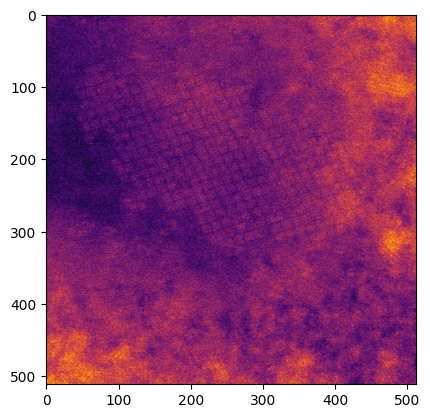

In [13]:
# Get image
starting_image, metadata = get_image()
plt.figure()
plt.imshow(starting_image, cmap='inferno')

# Get Stage
starting_position = mic.get_stage()
print('Stage position:', starting_position)

In [39]:
# First time will take ~35 seconds:
mic.set_screen_current(120) # pA


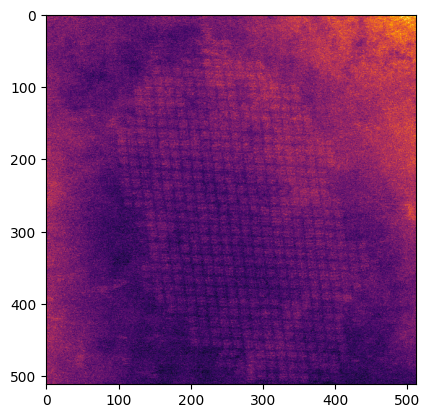

In [40]:
# Get image
starting_image, metadata = get_image()
plt.figure()
plt.imshow(starting_image, cmap='inferno')

In [41]:
set_currents = [50, 100, 150, 100,
                50, 100, 150, 100,
                50, 100, 150, 100,
                50, 100, 150, 100,
                50, 100, 150, 100,
                50]  # pA

In [42]:
# set_currents = [25, 50, 75, 100, 125, 150, 125, 100, 75, 50, 25]  # pA
real_currents = []
meta_images = []
for c in set_currents:
    print(f"\nSetting screen current to {c} pA...")
    mic.set_screen_current(c)

    time.sleep(10)  # wait for stabilization

    real_screen_current = mic.get_screen_current() * 1e12
    real_currents.append(real_screen_current)
    # auto-focus
    mic.auto_focus()

    # get 10 images
    images = []
    for i in range(10):
        image, metadata = get_image(dwell=10e-6, imsize=512)
        images.append(image)
    meta_images.append(images)



Setting screen current to 50 pA...

Setting screen current to 100 pA...

Setting screen current to 150 pA...

Setting screen current to 100 pA...

Setting screen current to 50 pA...

Setting screen current to 100 pA...

Setting screen current to 150 pA...

Setting screen current to 100 pA...

Setting screen current to 50 pA...

Setting screen current to 100 pA...

Setting screen current to 150 pA...

Setting screen current to 100 pA...

Setting screen current to 50 pA...

Setting screen current to 100 pA...

Setting screen current to 150 pA...

Setting screen current to 100 pA...

Setting screen current to 50 pA...

Setting screen current to 100 pA...

Setting screen current to 150 pA...

Setting screen current to 100 pA...

Setting screen current to 50 pA...


In [46]:
meta_images = np.array(meta_images)  
real_currents = np.array(real_currents)

print(meta_images.shape)

(21, 10, 512, 512)


In [47]:
filename = os.path.join(savefile_path, "beam_current_cycle_5.npz")
np.savez(
    filename,
    images=meta_images,
    currents=real_currents,
    set_currents=np.array(set_currents)
)

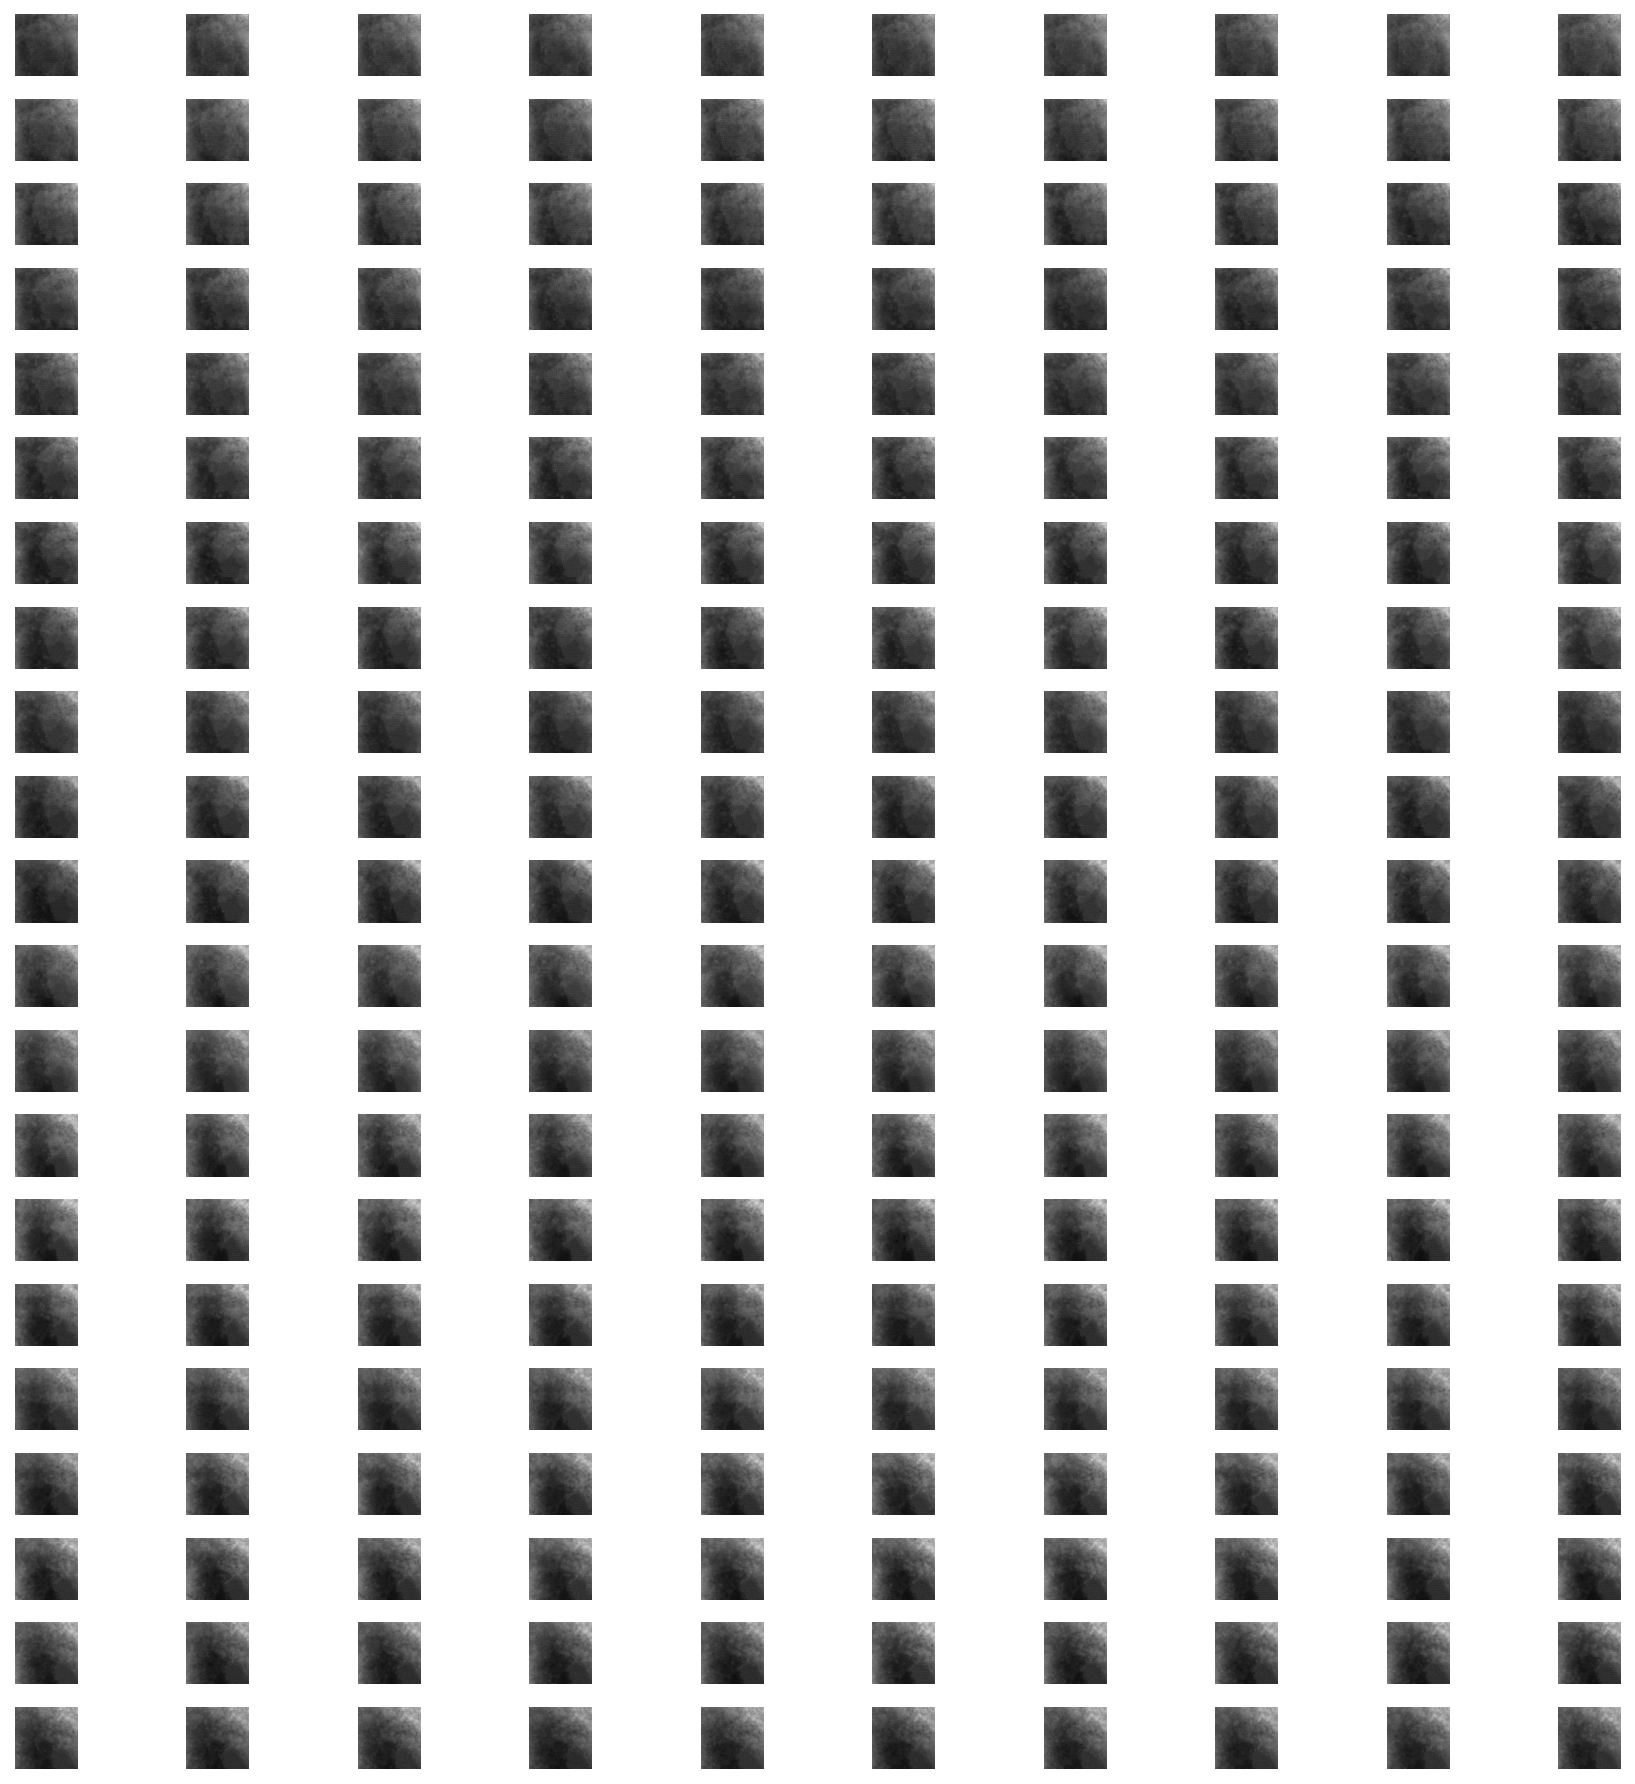

In [48]:
fig, ax = plt.subplots(len(set_currents), 10, figsize=(12, 12), dpi=150)

for i in range(len(set_currents)):
    for j in range(10):
        ax[i, j].imshow(meta_images[i, j], cmap='gray')
        ax[i, j].axis('off')

        if j == 0:
            ax[i, j].set_ylabel(f"{real_currents[i]:.0f} pA")

fig.tight_layout()

In [51]:
from skimage.feature import peak_local_max
from scipy.ndimage import gaussian_filter, center_of_mass

In [52]:
def detect_blobs(im):
    p99 = np.percentile(im.ravel(), 99)
    im = np.clip(im, 0, p99)
    smoothed = gaussian_filter(im, sigma=3)
    smoothed -= smoothed.min()
    smoothed /= smoothed.max()
    blobs = peak_local_max(smoothed, min_distance=6, threshold_abs=0.1)
    return blobs

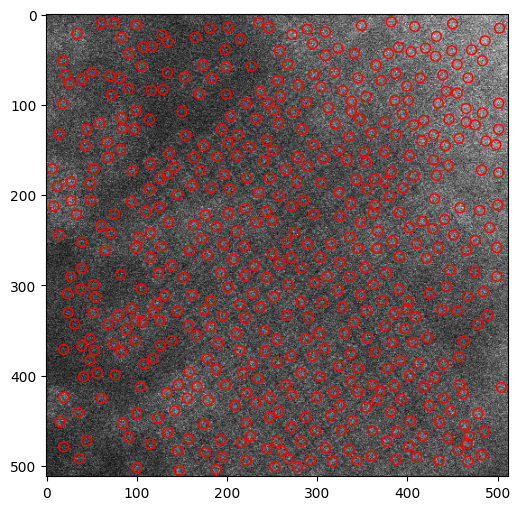

In [53]:
im = meta_images[0][0]

blobs = detect_blobs(im)

plt.figure(figsize=(6, 6))
plt.imshow(im, cmap='gray')
plt.scatter(blobs[:, 1], blobs[:, 0], s=50, edgecolor='red', facecolor='none')

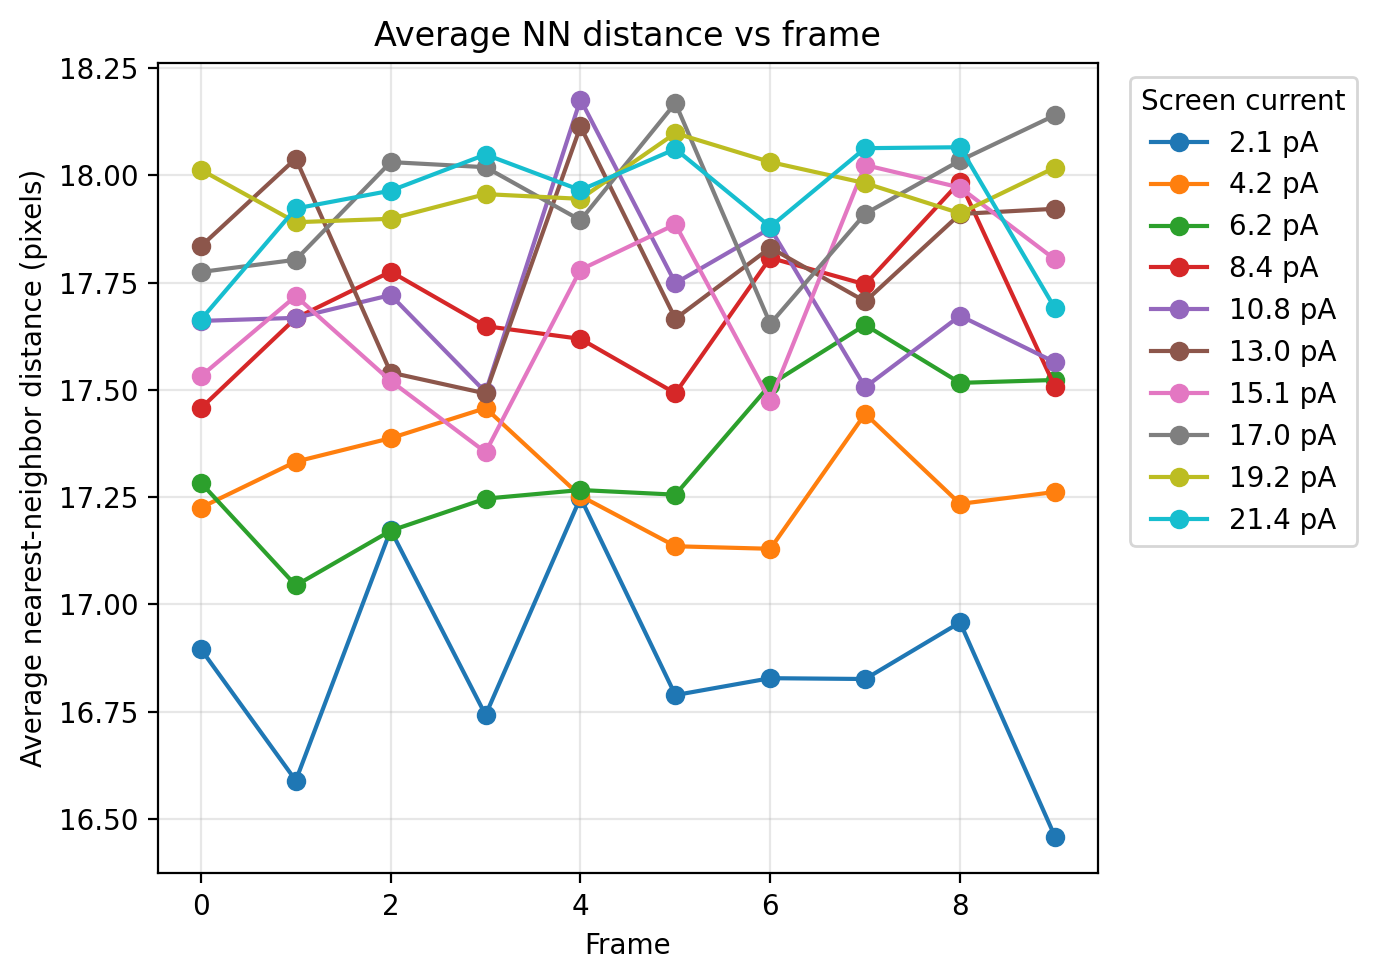

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# --- helper: average nearest-neighbor distance for one image ---
def average_nn_distance(image):
    blobs = detect_blobs(image)   # expected shape: (N, 2)

    if blobs is None or len(blobs) < 2:
        return np.nan

    tree = cKDTree(blobs)
    dists, _ = tree.query(blobs, k=2)   # first neighbor is self, second is true NN
    nn_dists = dists[:, 1]

    return np.mean(nn_dists)

# --- compute average NN distance for every frame in every row ---
avg_nn_by_row = []

for row in meta_images:   # each row corresponds to one current
    row_vals = []
    for im in row:
        row_vals.append(average_nn_distance(im))
    avg_nn_by_row.append(row_vals)

avg_nn_by_row = np.array(avg_nn_by_row)   # shape: (n_rows, n_frames)

# --- plot ---
fig, ax = plt.subplots(figsize=(7, 5), dpi=200)

n_rows, n_frames = avg_nn_by_row.shape
frames = np.arange(n_frames)

for i in range(n_rows):
    ax.plot(frames, avg_nn_by_row[i], marker='o', label=f"{real_currents[i]/10e12:.1f} pA")

ax.set_xlabel("Frame")
ax.set_ylabel("Average nearest-neighbor distance (pixels)")
ax.set_title("Average NN distance vs frame")
ax.legend(title="Screen current", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()